In [19]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv(r"C:\Users\jeron\OneDrive\Escritorio\Programacion\Charla_Redes_Neuronales\images_nn\data\train.csv")

In [21]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
data = np.array(df)
m, n = data.shape

In [23]:
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n] / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255

In [24]:
print(X_train.shape)
print(Y_train.shape)

(784, 41000)
(41000,)


In [25]:
def init_params():
    W1 = np.random.randn(10, 784) * 0.01
    b1 = np.zeros((10, 1))

    W2 = np.random.randn(10, 10) * 0.01
    b2 = np.zeros((10, 1))

    return W1, b1, W2, b2

def ReLu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLu(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_y = one_hot(Y)

    dZ2 = A2 - one_hot_y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, 1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * deriv_ReLu(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, 1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):

    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1

    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

In [26]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 50 == 0:
            print('Iteracion: ', i)
            accuracy = get_accuracy(get_predictions(A2), Y)
            print('Precision: ', accuracy)

    return W1, b1, W2, b2

In [27]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteracion:  0
Precision:  0.10004878048780488
Iteracion:  50
Precision:  0.3098780487804878
Iteracion:  100
Precision:  0.4959512195121951
Iteracion:  150
Precision:  0.7551219512195122
Iteracion:  200
Precision:  0.8236829268292682
Iteracion:  250
Precision:  0.8527317073170732
Iteracion:  300
Precision:  0.8677073170731707
Iteracion:  350
Precision:  0.877219512195122
Iteracion:  400
Precision:  0.8837073170731707
Iteracion:  450
Precision:  0.8887073170731707


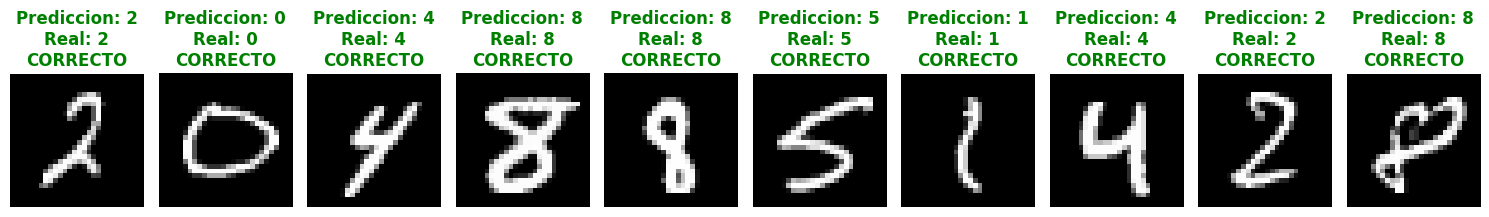


Precision total: 87.70%


In [ ]:
import matplotlib.pyplot as plt

def predict_and_visualize(W1, b1, W2, b2, X, Y, num_samples=5, start_index=None):
    """
    Hace predicciones y muestra las imágenes con el resultado
    
    Parametros:
    - num_samples: cantidad de imágenes a mostrar
    - start_index: índice de inicio. Si es None, elige aleatoriamente
    Si se proporciona, muestra num_samples consecutivas a partir de ese índice
    """
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    
    predictions = get_predictions(A2)
    
    
    if start_index is None:
        start_index = np.random.randint(0, X.shape[1] - num_samples)
    
    
    indices = np.arange(start_index, start_index + num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    
    if num_samples == 1:
        axes = [axes]
    
    for i, idx in enumerate(indices):
        
        image = X[:, idx].reshape(28, 28)
        
        pred = predictions[idx]
        actual = int(Y[idx])
        

        axes[i].imshow(image, cmap='gray')
        

        if pred == actual:
            title = f"Prediccion: {pred}\nReal: {actual}\nCORRECTO"
            axes[i].set_title(title, color='green', fontweight='bold')
        else:
            title = f"Prediccion: {pred}\nReal: {actual}\nINCORRECTO"
            axes[i].set_title(title, color='red', fontweight='bold')
        
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    
    accuracy = get_accuracy(predictions, Y)
    print(f"\nPrecision total: {accuracy*100:.2f}%")



predict_and_visualize(W1, b1, W2, b2, X_dev, Y_dev, num_samples=10, start_index=0)